In [1]:
#import bert_score
#from deepeval.metrics import GEval
#from deepeval.test_case import LLMTestCase, LLMTestCaseParams
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import pprint
from sklearn import metrics
import urllib

#from deepeval.models import AmazonBedrockModel

#import boto3
from pydantic_ai.models.bedrock import BedrockConverseModel
from pydantic_evals import Dataset, Case
from pydantic_evals.evaluators import LLMJudge
from pydantic_ai.settings import ModelSettings

import asyncio
import concurrent.futures

#from ragas.metrics import AnswerCorrectness 
#from ragas import EvaluationDataset, evaluate as ragas_evaluate
#from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#from ragas.llms import LangchainLLMWrapper
#from ragas.embeddings import LangchainEmbeddingsWrapper

import nest_asyncio
nest_asyncio.apply()

In [2]:
normalise_threshold=True

In [3]:
settings={}
settings["n_prompts"] = 3
settings["region"] = "eu-west-2"
settings["temperature"] = 0
settings["threshold"] = 0.5

In [4]:
models = {}

#models['Claude 3 Haiku'] = 'anthropic.claude-3-haiku-20240307-v1:0'
models['Claude 3.7 Sonnet'] = 'anthropic.claude-3-7-sonnet-20250219-v1:0'
#models['GPT OSS 20b'] = "openai.gpt-oss-20b-1:0"
models['GPT OSS 120b'] = "openai.gpt-oss-120b-1:0"

## Set Environment Variables

In [5]:
os.environ["AWS_DEFAULT_REGION"] = settings["region"]

## Get Data

In [6]:
datasets = [
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json'
   ]

In [7]:
for directory in ['data', 'output']:
    if not os.path.exists(directory):
        os.makedirs(directory)
    
for dataset in datasets:
    print(dataset)
    filename=dataset.split('/')[-1]
    if not os.path.isfile(f'data/{filename}'):
        print(f'downloading {filename}')
        urllib.request.urlretrieve(dataset, f'data/{filename}')

https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json


## Summarisation

In [14]:
rubric = """
You are a summary judge. You MUST determine if the provided summary contains non-factual or hallucinated information. The answer you give MUST be \"Yes\" or \"No\"
"""

summarisation_df = pd.read_json("data/summarization_data.json", lines=True)
summarisation_df

summarisation_not_hallucination_df = summarisation_df.copy()
summarisation_not_hallucination_df['summary'] = summarisation_not_hallucination_df['right_summary']
summarisation_not_hallucination_df['is_hallucination'] = False

summarisation_hallucination_df = summarisation_df.copy()
summarisation_hallucination_df['summary'] = summarisation_hallucination_df['hallucinated_summary']
summarisation_hallucination_df['is_hallucination'] = True

summarisation_answers_df = pd.concat([summarisation_not_hallucination_df, summarisation_hallucination_df])
summarisation_answers_df.reset_index(drop=True)
summarisation_answers_df

,document,right_summary,hallucinated_summary,summary,is_hallucination
0,"Marseille, France (CNN)The French prosecutor l...","Marseille prosecutor says ""so far no videos we...",A video showing the final moments of Germanwin...,"Marseille prosecutor says ""so far no videos we...",False
1,The Palestinian Authority officially became th...,Membership gives the ICC jurisdiction over all...,The International Criminal Court has officiall...,Membership gives the ICC jurisdiction over all...,False
2,Governments around the world are using the thr...,Amnesty's annual death penalty report catalogs...,Amnesty's annual report on the death penalty s...,Amnesty's annual death penalty report catalogs...,False
3,"On May 28, 2014, some 7,000 people gathered in...",Amnesty International releases its annual revi...,China paraded scores of prisoners at a mass se...,Amnesty International releases its annual revi...,False
4,"Seventy years ago, Anne Frank died of typhus i...",Museum: Anne Frank died earlier than previousl...,Anne Frank and her sister Margot were found al...,Museum: Anne Frank died earlier than previousl...,False
...,...,...,...,...,...
9995,Fired: Major General James Post III was fired ...,Major General James Post III was fired for say...,An Air Force major general was removed from hi...,An Air Force major general was removed from hi...,True
9996,"American Apparel, the controversial retailer k...",The print ad ran in the most recent issue of V...,American Apparel has launched a successful 'pr...,American Apparel has launched a successful 'pr...,True
9997,Angelina Jolie may have made the character wor...,Bonnie's skill at playing Call Of Duty has gai...,"Bonnie Doll, the real-life Lara Croft of Austr...","Bonnie Doll, the real-life Lara Croft of Austr...",True
9998,The disabled pensioner who received donations ...,"Alan Barnes, who is partially sighted and just...","Alan Barnes, a drug addict who was jailed for ...","Alan Barnes, a drug addict who was jailed for ...",True


In [53]:
def evaluate_pydantic(document: str, summary: str, settings: dict) -> dict:

    rubric = settings["rubric"]

    judge = LLMJudge(
        model=BedrockConverseModel(settings["model_id"]),
        rubric=rubric,
        score={'evaluation_name': 'HallucinationScore'},
        model_settings=ModelSettings(
            temperature=settings["temperature"],
            max_tokens=2048,
        ),
        include_input=True,
        include_expected_output=True,
    )

    dataset = Dataset(
        cases=[Case(inputs=document)],
        evaluators=[judge],
    )

    def run_in_thread():
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        try:
            return loop.run_until_complete(dataset.evaluate(lambda x: summary))
        finally:
            loop.close()

    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        report = executor.submit(run_in_thread).result()

    case_result = report.cases[0]
    score = 1 - case_result.scores['HallucinationScore'].value

    return {
        'method': 'Pydantic',
        'score': score,       # 0 = clean, 1 = fully hallucinated
        'reason': case_result.assertions['LLMJudge_pass'].reason,
        'passed': score >= settings['threshold']
    }

settings["rubric"] = """
    Your task is to detect hallucinations in a summary.
    
    DEFINITIONS:
    - HALLUCINATION: Any claim in the summary that is fabricated, exaggerated, contradicts, 
      or cannot be verified from the source document.
    - NOT A HALLUCINATION: Every claim in the summary can be directly verified or reasonably 
      inferred from the source document.
    
    SOURCE DOCUMENT:
    {input}
    
    SUMMARY TO EVALUATE:
    {output}
    
    INSTRUCTIONS:
    1. Read every factual claim in the SUMMARY.
    2. For each claim, check if it is supported by the SOURCE DOCUMENT.
    3. If ANY claim is unsupported or contradicted, the summary contains hallucinations.
    
    YOU MUST RESPOND WITH ONLY:
    - Score 0.0 if the summary contains ANY hallucinated content
    - Score 1.0 if every claim in the summary is fully supported by the source document
    
    Do not award partial scores. Be strict: if a claim cannot be verified, it is a hallucination.
    Provide a detailed explanation listing each hallucinated claim found.
"""

In [45]:
settings["rubric"] = """
    You are evaluating whether a summary (input) contains hallucinated content — 
    information that is fabricated, distorted, or not supported by the source document (expected_output).

    KNOWLEDGE BASE:
    {input}

    DIALOGUE HISTORY (context only, not ground truth):
    {expected_output}

    RESPONSE TO EVALUATE:
    {output}

    Score the summary from 0.0 to 1.0 where:
    - 0.0 = No hallucinations. Every claim in the summary is fully supported by the source document.
    - 0.25 = Minor hallucinations. Mostly accurate with 1-2 small unsupported details.
    - 0.5 = Moderate hallucinations. Several claims are inaccurate or unsupported.
    - 0.75 = Significant hallucinations. Many claims contradict or are absent from the source.
    - 1.0 = Severe hallucinations. The summary is largely fabricated or contradicts the document.

    Evaluate each factual claim in the summary and check whether it is:
    1. Explicitly stated in the source document (supported)
    2. Reasonably inferable from the source document (acceptable)
    3. Not present in the source document (unsupported — potential hallucination)
    4. Contradicted by the source document (hallucination)

    Return a score and a detailed explanation citing specific hallucinated claims if found.
    """.strip()

In [46]:
settings["rubric"] = """
    Your task is to detect hallucinations in a summary.
    
    DEFINITIONS:
    - HALLUCINATION: Any claim in the summary that is fabricated, exaggerated, contradicts, 
      or cannot be verified from the source document.
    - NOT A HALLUCINATION: Every claim in the summary can be directly verified or reasonably 
      inferred from the source document.
    
    SOURCE DOCUMENT:
    {input}
    
    SUMMARY TO EVALUATE:
    {output}
    
    INSTRUCTIONS:
    1. Read every factual claim in the SUMMARY.
    2. For each claim, check if it is supported by the SOURCE DOCUMENT.
    3. If ANY claim is unsupported or contradicted, the summary contains hallucinations.
    
    YOU MUST RESPOND WITH ONLY:
    - Score 0.0 if the summary contains ANY hallucinated content
    - Score 1.0 if every claim in the summary is fully supported by the source document
    
    Do not award partial scores. Be strict: if a claim cannot be verified, it is a hallucination.
    Provide a detailed explanation listing each hallucinated claim found.
"""

In [54]:
sample_df = summarisation_answers_df.sample(settings["n_prompts"])
#qa_sample_df = qa_answers_df[qa_answers_df["Question"]=="What happens to you if you eat watermelon seeds?"]

evaluations = []
for model_name, model_id in models.items():
    settings["model_name"] = model_name
    settings["model_id"] = model_id

    for row in sample_df.to_dict('records'):
        try:
            evaluation = evaluate_pydantic(row["document"], row["summary"], settings)
            evaluations.append(row|settings|evaluation)
            print(f"\ndocument:{row["document"]}\n\nsummary:{row["summary"]}\n\nanswer:{row["summary"]}\nhallucination: {row["is_hallucination"]}, score: {evaluation["score"]}\n")
        except:
            print('passing')
            pass

evaluations_df = pd.DataFrame(evaluations)
evaluations_df.to_csv('output/qanda_hallucinations.csv', index=False)
evaluations_df

Output()


document:The baggage handler who woke up from a nap inside the cargo hold of a flying plane did not realize until a piece of luggage fell on top of him. Alaska Airlines Flight 448 bound for Los Angeles was forced to return to Seattle-Tacoma International Airport Monday when passengers heard banging and pleas for help coming from beneath the aircraft. Today, the unnamed Seattle Airport employee revealed he might have slept much longer if it hadn't been for the passengers' bags. He told ABC News: 'When the bags started moving and I heard the sound of the engine, I had to think fast about what to do for me to get out.' Scroll down for audio and video. Can you hear me now? This is the moment an Alaska Airlines baggage handler was pulled from the cargo hold after falling asleep. Earlier, the terrified man called 911 begging the dispatcher for help. Safe: This is the baggage handler who fell asleep aboard the Alaska Airlines flight from Seattle to Los Angeles on Monday. In a desperate bid f

,document,right_summary,hallucinated_summary,summary,is_hallucination,n_prompts,region,temperature,threshold,rubric,model_name,model_id,method,score,reason,passed
0,The baggage handler who woke up from a nap ins...,Flight 448 had just taken off Monday when the ...,An Alaska Airlines baggage handler had a nap i...,An Alaska Airlines baggage handler had a nap i...,True,3,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The summary contains a hallucination: it state...,True
1,Prison life won't be pretty for Aaron Hernande...,Aaron Hernandez will serve life in Souza-Baran...,"Aaron Hernandez, a former NFL player and convi...",Aaron Hernandez will serve life in Souza-Baran...,False,3,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,0.0,I've carefully checked each claim in the summa...,False
2,A young boy enjoyed a rare opportunity to inte...,The boy named Gabriel holds his hands up to th...,A young boy was spotted playing with a brown b...,The boy named Gabriel holds his hands up to th...,False,3,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,0.0,I've carefully checked each claim in the summa...,False
3,The baggage handler who woke up from a nap ins...,Flight 448 had just taken off Monday when the ...,An Alaska Airlines baggage handler had a nap i...,An Alaska Airlines baggage handler had a nap i...,True,3,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,GPT OSS 120b,openai.gpt-oss-120b-1:0,Pydantic,1.0,The summary contains a hallucinated claim: it ...,True
4,Prison life won't be pretty for Aaron Hernande...,Aaron Hernandez will serve life in Souza-Baran...,"Aaron Hernandez, a former NFL player and convi...",Aaron Hernandez will serve life in Souza-Baran...,False,3,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,GPT OSS 120b,openai.gpt-oss-120b-1:0,Pydantic,0.0,All factual statements in the summary are dire...,False
5,A young boy enjoyed a rare opportunity to inte...,The boy named Gabriel holds his hands up to th...,A young boy was spotted playing with a brown b...,The boy named Gabriel holds his hands up to th...,False,3,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,GPT OSS 120b,openai.gpt-oss-120b-1:0,Pydantic,0.0,All factual claims in the summary are directly...,False


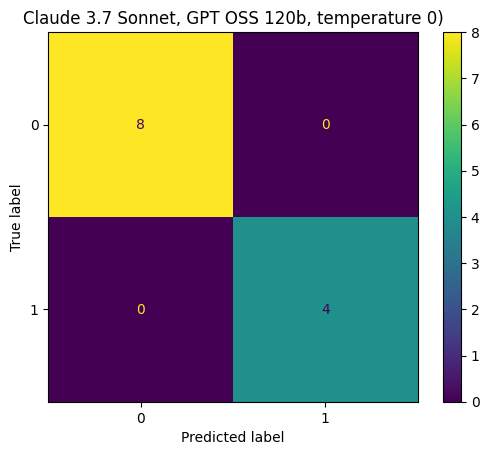

precision: 1.0, recall: 1.0, f1: 1.0

{'f1': 1.0,
 'model_name': 'Claude 3.7 Sonnet, GPT OSS 120b',
 'precision': 1.0,
 'recall': 1.0,
 'score_diff': np.float64(1.0),
 'score_hallucination': np.float64(1.0),
 'score_mean': np.float64(0.3333333333333333),
 'score_median': np.float64(0.0),
 'score_not_hallucination': np.float64(0.0),
 'temperature': '0'}


In [48]:
def get_results(df):
    results = {}

    results["model_name"] = f"{", ".join(df["model_name"].drop_duplicates().values)}"
    results["temperature"] = f"{str(df["temperature"].drop_duplicates().values[0])}"

    results["score_hallucination"] = df[df["is_hallucination"]]["score"].mean()
    results["score_not_hallucination"] = df[~df["is_hallucination"]]["score"].mean()
    results["score_diff"] = results["score_hallucination"] - results["score_not_hallucination"]
    results["score_mean"] = df["score_mean"].mean()
    results["score_median"] = df["score_median"].mean()
    #results["score_mean"] = (results["score_correct"] + results["score_incorrect"])/2
      
    results["precision"] = metrics.precision_score(df["is_hallucination"], df["passed"], zero_division=np.nan)
    results["recall"] = metrics.recall_score(df["is_hallucination"], df["passed"])
    results["f1"] = metrics.f1_score(df["is_hallucination"], df["passed"])
    confusion_matrix = metrics.confusion_matrix(df["is_hallucination"], df["passed"])
    
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
    cm_display.plot()
    #plt.title(f"{results["method"]} ({results["model_name"]})")
    plt.title(f"{results["model_name"]}, temperature {results["temperature"]})")
    plt.show()
    print(f"precision: {results["precision"]:.2}, recall: {results["recall"]:.2}, f1: {results["f1"]:.2}\n")
    
    return results

evaluations_df["score_mean"] = evaluations_df.groupby('model_name')['score'].transform('mean')
evaluations_df["score_median"] = evaluations_df.groupby('model_name')['score'].transform('median')

results = get_results(evaluations_df)
pprint.pprint(results)

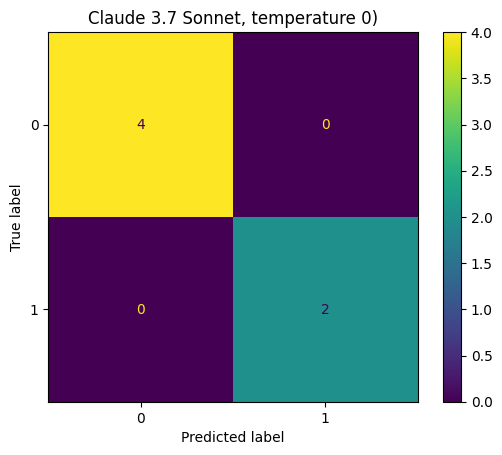

precision: 1.0, recall: 1.0, f1: 1.0



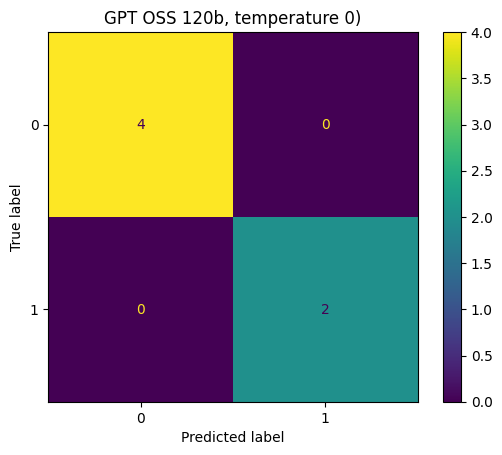

precision: 1.0, recall: 1.0, f1: 1.0



,model_name,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
0,Claude 3.7 Sonnet,0,1.0,0.0,1.0,0.333333,0.0,1.0,1.0,1.0
1,GPT OSS 120b,0,1.0,0.0,1.0,0.333333,0.0,1.0,1.0,1.0


In [49]:
results_models = []
for row in evaluations_df[['model_name']].drop_duplicates().to_dict('records'):
    filter_df = evaluations_df.copy()
    filter_df = filter_df[filter_df['model_name'] == row['model_name']]

    if len(filter_df) > 0:
        results = get_results(filter_df)
        results_models.append(results)

results_df = pd.DataFrame(results_models)
results_df.to_csv('output/results.csv', index=False)
results_df

,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
model_name,,,,,,,,,
Claude 3.7 Sonnet,0,1.0,0.0,1.0,0.333333,0.0,1.0,1.0,1.0
GPT OSS 120b,0,1.0,0.0,1.0,0.333333,0.0,1.0,1.0,1.0


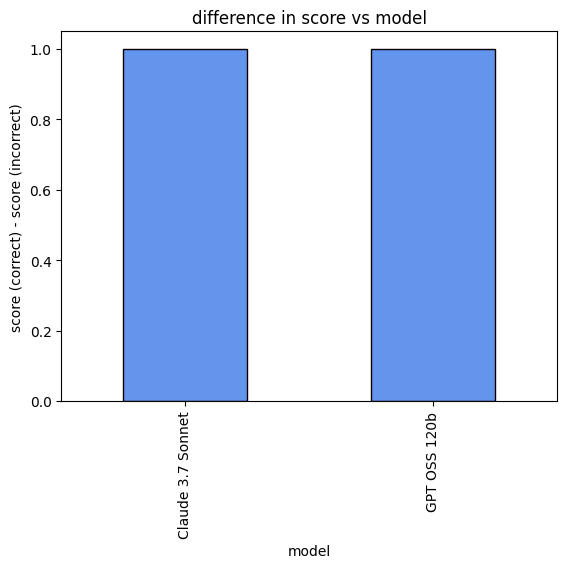

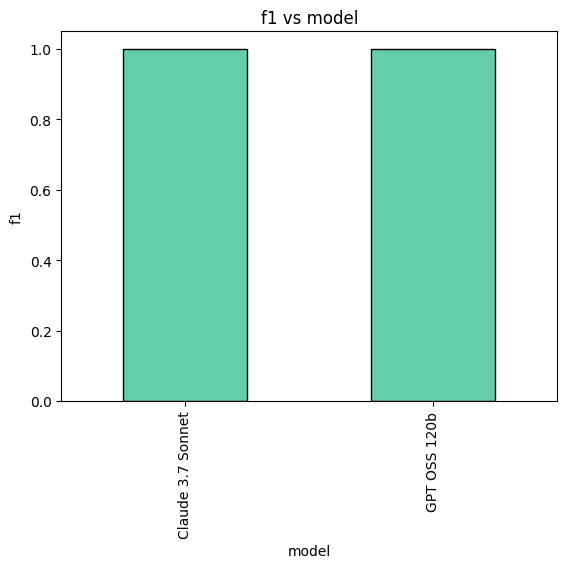

In [50]:
plot_df = results_df.set_index("model_name")

if len(plot_df) > 0:
    display(plot_df)
    plot_df["score_diff"].plot(kind="bar", xlabel="model",  ylabel="score (correct) - score (incorrect)", title=f"difference in score vs model", color="cornflowerblue", edgecolor="black")
    plt.show()
    plot_df["f1"].plot(kind="bar", xlabel="model", ylabel="f1", title=f"f1 vs model", color="mediumaquamarine", edgecolor="black")
    plt.show()